# The mnist datset is one with handwritten digits of 0-9

In [ ]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
!pip install shap

In [ ]:
(X_train,y_train),(X_test,y_test) = mnist.load_data()

In [ ]:
X_train.shape

(60000, 28, 28)

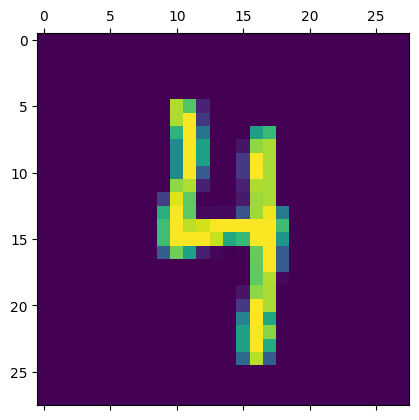

In [ ]:
plt.matshow(X_train[1110])

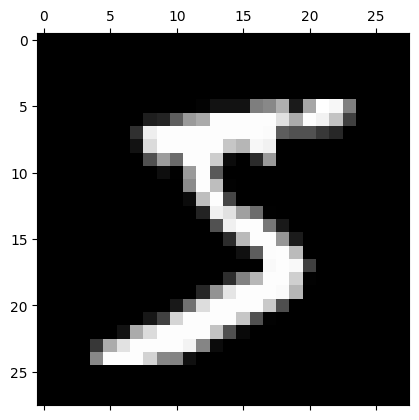

In [ ]:
plt.matshow(X_train[0],cmap="gray")

### We have to normalise the image Data


In [ ]:
X_train = X_train/255
X_test = X_test/255

In [ ]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

#### To add the depth of 1 to to the array of (600000 28 28 1)

In [ ]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

In [ ]:
X_train.shape

(60000, 28, 28, 1)

In [ ]:
X_test.shape

(10000, 28, 28, 1)

In [ ]:
y_train[:20]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9],
      dtype=uint8)

### Importing the Necessary Layers

In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import shap

In [ ]:
cnn_model = Sequential()
cnn_model.add(Input(shape=(28,28,1)))
cnn_model.add(Conv2D(filters = 16, kernel_size=(3,3), activation = "relu"))
cnn_model.add(Conv2D(filters = 32, kernel_size=(3,3), activation="relu"))
cnn_model.add(MaxPooling2D())
cnn_model.add(Conv2D(filters = 32, kernel_size=(3,3), activation="relu"))
cnn_model.add(MaxPooling2D())
cnn_model.add(Flatten())
cnn_model.add(Dense(units = 16, activation = "relu"))
cnn_model.add(Dense(units = 16, activation = "relu"))
cnn_model.add(Dense(units = 10, activation = "softmax"))

In [ ]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 10, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        12,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,306 (106.66 KB)

 Trainable params: 27,306 (106.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(loss = "sparse_categorical_crossentropy", optimizer = "adam", metrics = ["accuracy"])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
es = EarlyStopping(monitor="val_loss",
                  min_delta = 0.002,
                  patience = 5,
                  verbose = 1,
                  restore_best_weights = True)
                  #start from epoch =0 -- when should eraly stopping start its task

In [ ]:
history = cnn_model.fit(X_train, y_train,
                       epochs= 30,
                       verbose=1,
                       validation_split = 0.20,
                       batch_size = 3000,
                       callbacks= [es])

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9823 - loss: 0.0563 - val_accuracy: 0.9812 - val_loss: 0.0690
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9833 - loss: 0.0547 - val_accuracy: 0.9812 - val_loss: 0.0694
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1000ms/step - accuracy: 0.9837 - loss: 0.0518 - val_accuracy: 0.9810 - val_loss: 0.0671
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9845 - loss: 0.0507 - val_accuracy: 0.9809 - val_loss: 0.0692
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 992ms/step - accuracy: 0.9850 - loss: 0.0489 - val_accuracy: 0.9807 - val_loss: 0.0675
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.9855 - loss: 0.0482 - val_accuracy: 0.9793 - val_loss: 0.0685
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.9850 - loss: 0.0482 - val_accuracy: 0.9810 - val_loss: 0.0672
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.9860 - loss: 0.0453 - val_accuracy: 0.9818 - va

In [ ]:
X_train.shape

(60000, 28, 28, 1)

In [ ]:
cnn_model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.9814 - loss: 0.0573


[0.05727475509047508, 0.9814000129699707]

In [ ]:
y_proba = cnn_model.predict(X_test)
y_proba

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


array([[5.48102501e-11, 2.18232650e-08, 7.40483811e-05, ...,
        9.99912143e-01, 1.38086330e-06, 2.73513410e-06],
       [8.72251621e-06, 1.64309074e-03, 9.98321116e-01, ...,
        3.25714637e-07, 2.62006724e-05, 1.82849721e-12],
       [5.21517359e-06, 9.98209953e-01, 1.76426649e-04, ...,
        5.88768278e-04, 5.35564031e-04, 1.43152192e-06],
       ...,
       [2.18639221e-13, 3.71510933e-09, 1.64146607e-09, ...,
        1.60843128e-09, 1.34073741e-06, 1.48775882e-07],
       [1.05387905e-07, 8.38825699e-13, 2.63432353e-12, ...,
        1.49107375e-08, 2.16572244e-06, 7.56568497e-08],
       [1.12152343e-09, 5.16269388e-11, 5.98972649e-09, ...,
        2.36848496e-09, 7.19131643e-10, 6.35440173e-11]],
      shape=(10000, 10), dtype=float32)

In [ ]:
y_pred = [int(np.argmax(p)) for p in y_proba]
y_pred

[7,
 2,
 1,
 0,
 4,
 1,
 4,
 9,
 5,
 9,
 0,
 6,
 9,
 0,
 1,
 5,
 9,
 7,
 5,
 4,
 9,
 6,
 6,
 5,
 4,
 0,
 7,
 4,
 0,
 1,
 3,
 1,
 3,
 4,
 7,
 2,
 7,
 1,
 2,
 1,
 1,
 7,
 4,
 2,
 3,
 5,
 1,
 2,
 4,
 4,
 6,
 3,
 5,
 5,
 6,
 0,
 4,
 1,
 9,
 5,
 7,
 8,
 9,
 3,
 7,
 4,
 6,
 4,
 3,
 0,
 7,
 0,
 2,
 9,
 1,
 7,
 3,
 2,
 9,
 7,
 7,
 6,
 2,
 7,
 8,
 4,
 7,
 3,
 6,
 1,
 3,
 6,
 9,
 3,
 1,
 4,
 1,
 7,
 6,
 9,
 6,
 0,
 5,
 4,
 9,
 9,
 2,
 1,
 9,
 4,
 8,
 7,
 3,
 9,
 7,
 9,
 4,
 4,
 9,
 2,
 5,
 4,
 7,
 6,
 7,
 9,
 0,
 5,
 8,
 5,
 6,
 6,
 5,
 7,
 8,
 1,
 0,
 1,
 6,
 4,
 6,
 7,
 3,
 1,
 7,
 1,
 8,
 2,
 0,
 2,
 9,
 9,
 5,
 5,
 1,
 5,
 6,
 0,
 3,
 4,
 4,
 6,
 5,
 4,
 6,
 5,
 4,
 5,
 1,
 4,
 4,
 7,
 2,
 3,
 2,
 7,
 1,
 8,
 1,
 8,
 1,
 8,
 5,
 0,
 8,
 9,
 2,
 5,
 0,
 1,
 1,
 1,
 0,
 9,
 0,
 3,
 1,
 6,
 4,
 2,
 3,
 6,
 1,
 1,
 1,
 3,
 9,
 5,
 2,
 9,
 4,
 5,
 9,
 3,
 9,
 0,
 3,
 6,
 5,
 5,
 7,
 2,
 2,
 7,
 1,
 2,
 8,
 4,
 1,
 7,
 3,
 3,
 8,
 8,
 7,
 9,
 2,
 2,
 4,
 1,
 5,
 9,
 8,
 7,
 2,
 3,
 0,
 4,
 4,
 2,


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
cm=confusion_matrix(y_test, y_pred)
cm

array([[ 969,    0,    0,    0,    0,    2,    2,    2,    2,    3],
       [   0, 1127,    1,    2,    1,    0,    1,    1,    2,    0],
       [   5,    6, 1003,    1,    0,    0,    1,   10,    6,    0],
       [   0,    0,    3,  987,    0,   12,    0,    2,    2,    4],
       [   1,    0,    4,    0,  963,    0,    0,    2,    2,   10],
       [   2,    0,    0,    4,    0,  879,    5,    0,    0,    2],
       [   6,    1,    0,    0,    2,    1,  945,    0,    3,    0],
       [   0,    2,    8,    3,    0,    0,    0, 1012,    2,    1],
       [   6,    2,    4,    4,    1,    3,    0,    8,  941,    5],
       [   3,    3,    0,    1,    5,    3,    0,    4,    2,  988]])

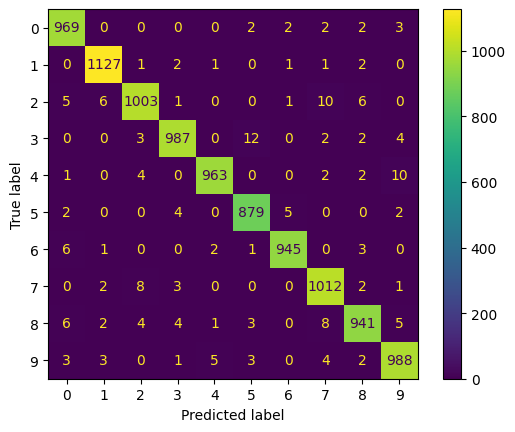

In [ ]:
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.99      0.98      0.98      1010
           4       0.99      0.98      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.97      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Deep Explainable AI

In [ ]:
import shap

In [ ]:
X_train.shape

In [ ]:

def get_unique_images(X_data,y_data):
    image_data = {}
    for i,label in enumerate(y_data):
        if len(image_data) == 10:
            break
    if label not in image_data:
        image_data[label] = X_data[i]
    return image_data


In [ ]:
train_img_dict = get_unique_images(X_train,y_train)
train_img_dict = dict(sorted(train_img_dict.items()))



In [ ]:
test_img_dict = get_unique_images(X_test,y_test)
test_img_dict = sorted(test_img_dict.items())
test_unique_img= [img[1] for img in test_img_dict]


In [ ]:
probablities = model.predict(test_unique_img)
y_pred = [np.argmax(prob) for prob in probablities]
y_pred

In [ ]:
def plot_ref_images(images_dict):
    fig, axes = plt.subplots(1, 11, figsize=(20, 15))
    # print(axes.flatten())
    ax = axes[0]
    dummy_array = np.array([[[0, 0, 0, 0]]], dtype='uint8')
    ax.imshow(dummy_array)
    ax.set_axis_off()

    for label_index, image in images_dict.items():
        ax = axes[label_index + 1]
        ax.imshow(image)
        ax.set_axis_off()

    plt.tight_layout()
    plt.show()

In [ ]:
shap.initjs()

In [ ]:
explainer = shap.DeepExplainer(model, X_train[:1000])

In [ ]:
explainer.expected_value

In [ ]:
shap_values = explainer.shap_values(test_unique_img)
len(shap_values)

In [ ]:
shap_values.shape

In [ ]:
#Reshape the shap value array for visualisation
shap_numpy = [np.swapaxes(np.swapaxes(s,0,-1),-1,-2)for s in shap_values]
shap_numpy[0].shape

In [ ]:
len(shap_numpy)

In [ ]:
shap.image_plot?

In [ ]:
plot_ref_images(train_img_dict)
shap.image_plot(shap_values, test_unique_img*255)